# NK Neighborhood Analysis

This notebook identifies which cell types are spatially near NK cells, summarizes NK-neighborhood composition per tissue, and compares NK neighborhoods across treatment groups.

**Main comparison:** `RTCyPSCA_Tu1` vs `CyPSCA_Tu1`  
**Statistical unit:** tissue section/sample  
**Primary anchor:** all NK cells  
**Optional anchor:** `GranzymeDeath_GO`-high NK cells using the curated GO Biological Process pathway `GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY`

The main outputs answer:

1. Which cell types are most prevalent near NK cells?
2. Which cell types are enriched near NK cells compared with tissue background?
3. Do NK neighborhoods differ between `CyPSCA_Tu1` and `RTCyPSCA_Tu1`?
4. Are high-granzyme NK cells located in different neighborhoods than all NK cells?

## Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp

import scanpy as sc
import spatialdata as spd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import NearestNeighbors
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## Configuration

Edit this block to control which treatments are analyzed, what counts as a neighborhood, which cells are anchors, and which groups are compared statistically.

In [ ]:
# ============================================================================
# ── PATHS ────────────────────────────────────────────────────────────────────
# ============================================================================

# Gemini
# zarr_file = "/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/processing_Zarr/1_C2l_annotations_400"
#Laptop
zarr_file = "/Users/janzules/Roselab/Spatial/CAR_T/data/zarrFiles/1_C2l_annotations_400"

reference_dir = Path("/coh_labs/yunroseli/Jona/CAR-T/data/references")
pathway_dir = reference_dir / "pathways"

outdir = Path("/coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis")
outdir.mkdir(parents=True, exist_ok=True)

# ============================================================================
# ── ANNOTATION COLUMNS ───────────────────────────────────────────────────────
# ============================================================================

celltype_col = "c2l_consolidated"
sample_col = "tissue"
condition_col = "treatment"

# ============================================================================
# ── TREATMENTS TO INCLUDE ────────────────────────────────────────────────────
# ============================================================================

analysis_treatments = [
    "NoTx_Tu1",
    "CyT72_Tu1",
    "CyPSCA_Tu1",
    "CyPSCA_Tu2"
    "RTCyT72_Tu1",
    "RTCyPSCA_Tu1",
    "RTCyPSCA_Tu2",
]

plot_order = analysis_treatments

# Primary statistical comparison
group_a = "CyPSCA_Tu1"
group_b = "RTCyPSCA_Tu1"

# ============================================================================
# ── NEIGHBORHOOD SETTINGS ────────────────────────────────────────────────────
# ============================================================================

# k-nearest-neighbor neighborhood around each NK cell.
# This avoids needing exact micron calibration and controls for local density differences.
k_neighbors = 25

# Minimum number of NK anchor cells required to analyze a tissue
min_anchor_cells = 10

# Anchor cell type
anchor_cell_type = "NK"

# ============================================================================
# ── CELL TYPE ORDER FOR PLOTS ────────────────────────────────────────────────
# ============================================================================

celltype_order = [
    "Cancer_cell",
    "M1_like_Mac",
    "M2_like_Mac",
    "Intermediate_Mac",
    "Macrophage",
    "Classical_Mono",
    "Nonclassical_Mono",
    "Monocyte",
    "cDC",
    "pDC",
    "DC",
    "B",
    "CD8_T",
    "CD4_T",
    "Treg",
    "Tcell"
    "NK",
    "NKT",
    "N1_like_Neu",
    "N2_like_Neu",
    "Fibroblast",
    "Endothelial",
    "Erythrocyte",
    "Unknown"
]

print(f"Output directory: {outdir}")
print(f"Anchor cell type: {anchor_cell_type}")
print(f"k-neighbors around each NK cell: {k_neighbors}")
print(f"Primary comparison: {group_b} vs {group_a}")

Output directory: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis
Anchor cell type: NK
k-neighbors around each NK cell: 25
Primary comparison: RTCyPSCA_Tu1 vs CyPSCA_Tu1


## Load data

In [3]:
sdata = spd.read_zarr(zarr_file)
adata = sdata.tables["segmentation_counts"]

print(adata)
print()
print("obs columns:")
print(adata.obs.columns.tolist())
print()
print("obsm keys:")
print(list(adata.obsm.keys()))

AnnData object with n_obs × n_vars = 2088557 × 19059
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', 'c2l_argmax', 'c2l_permissive', 'c2l_strict', 'c2l_runnerup', 'c2l_consolidated', 'treatment'
    uns: 'spatialdata_attrs', 'log1p', 'normalization'
    obsm: 'c2l_means', 'spatial', 'c2l_q95', 'c2l_q05'
    layers: 'counts'

obs columns:
['sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', 'c2l_argmax', 'c2l_permissive', 'c2l_strict', 'c2l_runnerup', 'c2l_consolidated', 'treatment']

obsm keys:
['c2l_means', 'spatial', 'c2l_q95', 'c2l_q05']


## Confirm metadata

This verifies that the tissue names have been parsed into `condition`, `tumor_loc`, `replicate_num`, and `treatment`. It will only parse them if the columns are missing.

In [4]:
needed_cols = ["condition", "tumor_loc", "replicate_num", "treatment"]

if not all(col in adata.obs.columns for col in needed_cols):
    tissue_str = adata.obs["tissue"].astype(str)

    parts = tissue_str.str.rsplit("_", n=2, expand=True)
    parts.columns = ["condition", "tumor_loc", "replicate_num"]

    adata.obs["condition"] = parts["condition"].values
    adata.obs["tumor_loc"] = parts["tumor_loc"].values
    adata.obs["replicate_num"] = parts["replicate_num"].values
    adata.obs["treatment"] = (
        parts["condition"].astype(str) + "_Tu" + parts["tumor_loc"].astype(str)
    ).values
else:
    print("Metadata columns already exist. Keeping existing columns.")

display(
    adata.obs[["tissue", "condition", "tumor_loc", "replicate_num", "treatment"]]
    .drop_duplicates()
    .sort_values("tissue")
)

Metadata columns already exist. Keeping existing columns.


,tissue,condition,tumor_loc,replicate_num,treatment
F07839_1n2_OME_cellid_000000001-1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1
F07840_123_OME_cellid_000000001-1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1
F08638_OME_cellid_000139764-1,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1
F08637_OME_cellid_000102296-1,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1
F08636_OME_cellid_000012222-1,CyPSCA_2_1,CyPSCA,2,1,CyPSCA_Tu2
F08637_OME_cellid_000011520-1,CyPSCA_2_2,CyPSCA,2,2,CyPSCA_Tu2
F08635_OME_cellid_000030410-1,CyPSCA_2_3,CyPSCA,2,3,CyPSCA_Tu2
F08542_1n3_OME_cellid_000124231-1,CyPSCA_2_4,CyPSCA,2,4,CyPSCA_Tu2
F08543_OME_cellid_000000001-1,CyT72_1_2,CyT72,1,2,CyT72_Tu1
F07840_123_OME_cellid_000139696-1,CyT72_1_4,CyT72,1,4,CyT72_Tu1


In [5]:
print("Available cell annotations:")
print(sorted(adata.obs[celltype_col].dropna().astype(str).unique()))

print()
print("Tissues per selected treatment:")
display(
    adata.obs.loc[
        adata.obs[condition_col].astype(str).isin(analysis_treatments),
        ["tissue", "condition", "tumor_loc", "replicate_num", "treatment"]
    ]
    .drop_duplicates()
    .sort_values(["treatment", "tissue"])
)

Available cell annotations:
['B', 'CD4_T', 'CD8_T', 'Cancer_cell', 'Classical_Mono', 'DC', 'Endothelial', 'Erythrocyte', 'Fibroblast', 'Intermediate_Mac', 'M1_like_Mac', 'M2_like_Mac', 'Macrophage', 'Monocyte', 'N1_like_Neu', 'N2_like_Neu', 'NK', 'NKT', 'Neutrophil', 'Nonclassical_Mono', 'Tcell', 'Treg', 'Unknown', 'cDC', 'pDC']

Tissues per selected treatment:


,tissue,condition,tumor_loc,replicate_num,treatment
F07839_1n2_OME_cellid_000000001-1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1
F07840_123_OME_cellid_000000001-1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1
F08638_OME_cellid_000139764-1,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1
F08637_OME_cellid_000102296-1,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1
F08543_OME_cellid_000000001-1,CyT72_1_2,CyT72,1,2,CyT72_Tu1
F07840_123_OME_cellid_000139696-1,CyT72_1_4,CyT72,1,4,CyT72_Tu1
F08635_OME_cellid_000000003-1,NoTx_1_1,NoTx,1,1,NoTx_Tu1
F08636_OME_cellid_000000001-1,NoTx_1_2,NoTx,1,2,NoTx_Tu1
F08637_OME_cellid_000000001-1,NoTx_1_3,NoTx,1,3,NoTx_Tu1
F08542_1n3_OME_cellid_000129215-1,NoTx_1_4,NoTx,1,4,NoTx_Tu1


## Optional: normalize and score GranzymeDeath_GO pathway

This is only needed if you want to define high-granzyme NK anchors later.

Neighborhood composition around **all NK cells** does not require gene-expression normalization. The optional high-granzyme NK analysis does.

In [7]:
# Set to False if you only want all-NK neighborhood composition.
run_expression_scoring = True

# if run_expression_scoring:
#     # This modifies only the in-memory AnnData unless you explicitly write it back.
#     # The zarr file on disk is not modified by this notebook.
#     sc.pp.normalize_total(adata, target_sum=1e4, inplace=True)
#     sc.pp.log1p(adata)

#     adata.uns["normalization"] = {
#         "method": "scanpy.pp.normalize_total + log1p",
#         "target_sum": 1e4,
#         "purpose": "GranzymeDeath_GO scoring for NK-high anchor analysis",
#     }

#     print("Normalized adata.X with normalize_total(target_sum=1e4) + log1p.")
# else:
#     print("Skipping expression normalization/scoring.")

In [8]:
def read_gmt(gmt_path):
    gene_sets = {}
    with open(gmt_path, "r") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            gene_sets[parts[0]] = parts[2:]
    return gene_sets


if run_expression_scoring:
    go_bp_gmt = pathway_dir / "m5.go.bp.v2026.1.Mm.symbols.gmt"
    go_sets = read_gmt(go_bp_gmt)

    granzyme_pathway = "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY"

    if granzyme_pathway not in go_sets:
        raise ValueError(f"{granzyme_pathway} not found in {go_bp_gmt}")

    genes = go_sets[granzyme_pathway]
    genes_present = [g for g in genes if g in adata.var_names]
    genes_missing = [g for g in genes if g not in adata.var_names]

    print(f"Granzyme pathway genes total: {len(genes)}")
    print(f"Present in adata: {len(genes_present)}")
    print(f"Missing from adata: {len(genes_missing)}")
    print("Present genes:")
    print(genes_present)

    sc.tl.score_genes(
        adata,
        gene_list=genes_present,
        score_name="GranzymeDeath_GO_score",
        use_raw=False,
    )

    nk_mask = adata.obs[celltype_col].astype(str).eq("NK")
    nk_q75 = adata.obs.loc[nk_mask, "GranzymeDeath_GO_score"].quantile(0.75)
    nk_q90 = adata.obs.loc[nk_mask, "GranzymeDeath_GO_score"].quantile(0.90)

    adata.obs["NK_GranzymeDeath_q75_high"] = (
        nk_mask & (adata.obs["GranzymeDeath_GO_score"] >= nk_q75)
    )
    adata.obs["NK_GranzymeDeath_q90_high"] = (
        nk_mask & (adata.obs["GranzymeDeath_GO_score"] >= nk_q90)
    )

    print(f"NK-specific GranzymeDeath q75 threshold: {nk_q75:.4f}")
    print(f"NK-specific GranzymeDeath q90 threshold: {nk_q90:.4f}")

Granzyme pathway genes total: 11
Present in adata: 10
Missing from adata: 1
Present genes:
['Bnip3', 'Gzma', 'Gzmb', 'Gzmc', 'Gzmk', 'Lamp1', 'Nkg7', 'Prf1', 'Srgn', 'Ube4b']
NK-specific GranzymeDeath q75 threshold: 0.5878
NK-specific GranzymeDeath q90 threshold: 1.0343


## Define analysis tissues

In [9]:
analysis_tissues = (
    adata.obs.loc[
        adata.obs[condition_col].astype(str).isin(analysis_treatments),
        sample_col
    ]
    .astype(str)
    .unique()
    .tolist()
)

analysis_tissues = sorted(analysis_tissues)

print(f"Number of tissues included: {len(analysis_tissues)}")
print(analysis_tissues)

Number of tissues included: 16
['CyPSCA_1_1', 'CyPSCA_1_2', 'CyPSCA_1_3', 'CyPSCA_1_4', 'CyT72_1_2', 'CyT72_1_4', 'NoTx_1_1', 'NoTx_1_2', 'NoTx_1_3', 'NoTx_1_4', 'RTCyPSCA_1_2', 'RTCyPSCA_1_3', 'RTCyPSCA_1_4', 'RTCyPSCA_1_5', 'RTCyPSCA_2_3', 'RTCyPSCA_2_4']


# Main analysis: cell types near NK cells

For each tissue:

1. Identify all NK cells.
2. Find the `k_neighbors` nearest neighboring cells around each NK cell.
3. Count the cell types of those neighbors.
4. Compare neighborhood cell-type fractions to the tissue-wide background.

Important output columns:

| Column | Meaning |
|---|---|
| `neighbor_fraction` | Of all cells in NK neighborhoods, what fraction are this target cell type? |
| `anchor_prevalence` | What fraction of NK cells have at least one neighbor of this target cell type? |
| `background_fraction` | How common is this cell type in the whole tissue? |
| `enrichment_log2` | log2(neighbor fraction / tissue background fraction) |

## Compute NK-neighborhood composition per tissue

In [10]:
neighbor_rows = []

for tissue in analysis_tissues:
    print(f"\nProcessing tissue: {tissue}")

    tissue_mask = adata.obs[sample_col].astype(str).eq(tissue).values
    obs_t = adata.obs.loc[tissue_mask].copy()
    coords_t = adata.obsm["spatial"][tissue_mask]

    labels_t = obs_t[celltype_col].astype(str).values
    treatment_t = obs_t[condition_col].astype(str).iloc[0]
    condition_t = obs_t["condition"].astype(str).iloc[0]
    tumor_loc_t = obs_t["tumor_loc"].astype(str).iloc[0]
    replicate_t = obs_t["replicate_num"].astype(str).iloc[0]

    anchor_mask_t = labels_t == anchor_cell_type
    anchor_local_idx = np.where(anchor_mask_t)[0]

    n_cells_t = obs_t.shape[0]
    n_anchor_t = len(anchor_local_idx)

    print(f"  total cells: {n_cells_t:,}")
    print(f"  NK anchors:  {n_anchor_t:,}")

    if n_anchor_t < min_anchor_cells:
        print(f"  Skipping: fewer than {min_anchor_cells} NK anchors.")
        continue

    n_query_neighbors = min(k_neighbors + 1, n_cells_t)

    nn = NearestNeighbors(
        n_neighbors=n_query_neighbors,
        algorithm="auto"
    )
    nn.fit(coords_t)

    neighbor_idx_raw = nn.kneighbors(
        coords_t[anchor_local_idx],
        return_distance=False
    )

    # Remove self-neighbor for each NK anchor and keep exactly k_neighbors.
    neighbor_idx_clean = []

    for row_i, neighs in enumerate(neighbor_idx_raw):
        self_idx = anchor_local_idx[row_i]
        clean = [idx for idx in neighs if idx != self_idx]
        clean = clean[:k_neighbors]
        neighbor_idx_clean.append(clean)

    neighbor_idx_clean = np.array(neighbor_idx_clean, dtype=int)

    # Flatten all neighbor labels.
    neighbor_labels = labels_t[neighbor_idx_clean.ravel()]

    # Tissue background composition.
    background_counts = pd.Series(labels_t).value_counts()
    background_fraction = background_counts / background_counts.sum()

    # NK-neighborhood composition.
    neighbor_counts = pd.Series(neighbor_labels).value_counts()
    neighbor_fraction = neighbor_counts / neighbor_counts.sum()

    # Per-anchor presence of each target cell type.
    neighbor_label_matrix = labels_t[neighbor_idx_clean]

    all_labels_this_tissue = sorted(set(labels_t).union(set(neighbor_labels)))

    for target in all_labels_this_tissue:
        n_neighbor_target = int((neighbor_labels == target).sum())
        frac_neighbor_target = float(neighbor_fraction.get(target, 0.0))
        frac_background_target = float(background_fraction.get(target, 0.0))

        anchor_has_target = (neighbor_label_matrix == target).any(axis=1)
        anchor_prevalence = float(anchor_has_target.mean())

        eps = 1e-6
        enrichment_log2 = np.log2(
            (frac_neighbor_target + eps) /
            (frac_background_target + eps)
        )

        neighbor_rows.append({
            "tissue": tissue,
            "condition": condition_t,
            "tumor_loc": tumor_loc_t,
            "replicate_num": replicate_t,
            "treatment": treatment_t,
            "anchor_cell_type": anchor_cell_type,
            "target_cell_type": target,
            "n_cells_tissue": n_cells_t,
            "n_anchor_cells": n_anchor_t,
            "k_neighbors": k_neighbors,
            "n_neighbor_slots": int(n_anchor_t * k_neighbors),
            "n_neighbor_target": n_neighbor_target,
            "neighbor_fraction": frac_neighbor_target,
            "anchor_prevalence": anchor_prevalence,
            "background_fraction": frac_background_target,
            "enrichment_log2": enrichment_log2,
        })

nk_neighbor_summary = pd.DataFrame(neighbor_rows)

# Keep consistent plotting order where possible.
present_order = [
    x for x in celltype_order
    if x in nk_neighbor_summary["target_cell_type"].astype(str).unique()
]

nk_neighbor_summary["target_cell_type"] = pd.Categorical(
    nk_neighbor_summary["target_cell_type"].astype(str),
    categories=present_order,
    ordered=True,
)

display(nk_neighbor_summary.head())

nk_neighbor_summary.to_csv(
    outdir / "NK_neighborhood_celltype_summary_per_tissue.csv",
    index=False,
)

print(f"Saved: {outdir / 'NK_neighborhood_celltype_summary_per_tissue.csv'}")


Processing tissue: CyPSCA_1_1
  total cells: 108,895
  NK anchors:  2,400

Processing tissue: CyPSCA_1_2
  total cells: 55,540
  NK anchors:  722

Processing tissue: CyPSCA_1_3
  total cells: 33,085
  NK anchors:  247

Processing tissue: CyPSCA_1_4
  total cells: 27,025
  NK anchors:  252

Processing tissue: CyT72_1_2
  total cells: 34,108
  NK anchors:  154

Processing tissue: CyT72_1_4
  total cells: 49,785
  NK anchors:  340

Processing tissue: NoTx_1_1
  total cells: 44,929
  NK anchors:  19

Processing tissue: NoTx_1_2
  total cells: 23,792
  NK anchors:  116

Processing tissue: NoTx_1_3
  total cells: 59,018
  NK anchors:  181

Processing tissue: NoTx_1_4
  total cells: 34,688
  NK anchors:  342

Processing tissue: RTCyPSCA_1_2
  total cells: 28,637
  NK anchors:  34

Processing tissue: RTCyPSCA_1_3
  total cells: 57,620
  NK anchors:  102

Processing tissue: RTCyPSCA_1_4
  total cells: 69,639
  NK anchors:  78

Processing tissue: RTCyPSCA_1_5
  total cells: 35,860
  NK anchors:

,tissue,condition,tumor_loc,replicate_num,treatment,anchor_cell_type,target_cell_type,n_cells_tissue,n_anchor_cells,k_neighbors,n_neighbor_slots,n_neighbor_target,neighbor_fraction,anchor_prevalence,background_fraction,enrichment_log2
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,NK,B,108895,2400,25,60000,1939,0.032317,0.514583,0.020671,0.644625
1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,NK,CD4_T,108895,2400,25,60000,1440,0.024000,0.398750,0.011001,1.125273
2,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,NK,CD8_T,108895,2400,25,60000,5456,0.090933,0.790000,0.049102,0.889004
3,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,NK,Cancer_cell,108895,2400,25,60000,8583,0.143050,0.796667,0.082850,0.787931
4,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,NK,Classical_Mono,108895,2400,25,60000,608,0.010133,0.112917,0.041085,-2.019411


Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/NK_neighborhood_celltype_summary_per_tissue.csv


## Inspect NK-neighborhood composition

In [11]:
focus_targets = [
    "Cancer_cell",
    "M1_like_Mac",
    "M2_like_Mac",
    "Intermediate_Mac",
    "Classical_Mono",
    "cDC",
    "CD8_T",
    "NK",
    "NKT",
    "Fibroblast",
    "Endothelial",
]

inspect_df = nk_neighbor_summary.loc[
    nk_neighbor_summary["target_cell_type"].astype(str).isin(focus_targets)
].copy()

display(
    inspect_df
    .sort_values(["treatment", "target_cell_type", "tissue"])
    [[
        "tissue",
        "treatment",
        "target_cell_type",
        "n_anchor_cells",
        "neighbor_fraction",
        "anchor_prevalence",
        "background_fraction",
        "enrichment_log2",
    ]]
)

,tissue,treatment,target_cell_type,n_anchor_cells,neighbor_fraction,anchor_prevalence,background_fraction,enrichment_log2
3,CyPSCA_1_1,CyPSCA_Tu1,Cancer_cell,2400,0.143050,0.796667,0.082850,0.787931
28,CyPSCA_1_2,CyPSCA_Tu1,Cancer_cell,722,0.200222,0.782548,0.222866,-0.154581
52,CyPSCA_1_3,CyPSCA_Tu1,Cancer_cell,247,0.020567,0.246964,0.019163,0.102007
75,CyPSCA_1_4,CyPSCA_Tu1,Cancer_cell,252,0.054603,0.531746,0.047216,0.209719
10,CyPSCA_1_1,CyPSCA_Tu1,M1_like_Mac,2400,0.002600,0.049167,0.012452,-2.259397
...,...,...,...,...,...,...,...,...
360,RTCyPSCA_2_4,RTCyPSCA_Tu2,NKT,1091,0.004986,0.117324,0.003070,0.699767
327,RTCyPSCA_2_3,RTCyPSCA_Tu2,Fibroblast,298,0.000805,0.020134,0.001102,-0.452390
351,RTCyPSCA_2_4,RTCyPSCA_Tu2,Fibroblast,1091,0.023795,0.277727,0.021947,0.116611
325,RTCyPSCA_2_3,RTCyPSCA_Tu2,Endothelial,298,0.002685,0.046980,0.002000,0.424324


# Statistics: compare NK neighborhoods between treatments

In [12]:
def cliffs_delta_b_vs_a(a, b):
    # Positive value means group_b tends to be higher than group_a.
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    greater = 0
    less = 0

    for bi in b:
        greater += np.sum(bi > a)
        less += np.sum(bi < a)

    return (greater - less) / (len(a) * len(b))


def permutation_test_mean_diff(a, b, n_perm=10000, alternative="two-sided", seed=42):
    # Tests mean(b) - mean(a).
    rng = np.random.default_rng(seed)

    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    observed = b.mean() - a.mean()
    pooled = np.concatenate([a, b])
    n_a = len(a)

    perm_diffs = np.empty(n_perm)

    for i in range(n_perm):
        shuffled = rng.permutation(pooled)
        perm_a = shuffled[:n_a]
        perm_b = shuffled[n_a:]
        perm_diffs[i] = perm_b.mean() - perm_a.mean()

    if alternative == "greater":
        p = np.mean(perm_diffs >= observed)
    elif alternative == "less":
        p = np.mean(perm_diffs <= observed)
    else:
        p = np.mean(np.abs(perm_diffs) >= abs(observed))

    return observed, p

## Compare each neighboring cell type

This compares `RTCyPSCA_Tu1` against `CyPSCA_Tu1`, using one value per tissue.

Positive `mean_difference_b_minus_a` and positive `cliffs_delta_b_vs_a` mean that the target cell type is more prevalent/enriched near NK cells in `RTCyPSCA_Tu1`.

In [13]:
metrics_to_compare = [
    "neighbor_fraction",
    "anchor_prevalence",
    "enrichment_log2",
]

stat_rows = []

for target in nk_neighbor_summary["target_cell_type"].dropna().astype(str).unique():
    target_df = nk_neighbor_summary.loc[
        nk_neighbor_summary["target_cell_type"].astype(str).eq(target)
    ].copy()

    for metric in metrics_to_compare:
        a = target_df.loc[
            target_df["treatment"].eq(group_a),
            metric
        ].dropna()

        b = target_df.loc[
            target_df["treatment"].eq(group_b),
            metric
        ].dropna()

        if len(a) >= 2 and len(b) >= 2:
            mw_two = mannwhitneyu(a, b, alternative="two-sided", method="auto")
            mw_greater = mannwhitneyu(a, b, alternative="less", method="auto")  # b > a

            mean_diff, perm_p_two = permutation_test_mean_diff(
                a,
                b,
                n_perm=10000,
                alternative="two-sided",
                seed=42,
            )

            _, perm_p_greater = permutation_test_mean_diff(
                a,
                b,
                n_perm=10000,
                alternative="greater",
                seed=42,
            )

            delta = cliffs_delta_b_vs_a(a, b)

        else:
            mean_diff = np.nan
            perm_p_two = np.nan
            perm_p_greater = np.nan
            delta = np.nan
            mw_two = None
            mw_greater = None

        stat_rows.append({
            "target_cell_type": target,
            "metric": metric,
            "group_a": group_a,
            "group_b": group_b,
            "n_group_a": len(a),
            "n_group_b": len(b),
            "mean_group_a": a.mean(),
            "mean_group_b": b.mean(),
            "median_group_a": a.median(),
            "median_group_b": b.median(),
            "mean_difference_b_minus_a": mean_diff,
            "cliffs_delta_b_vs_a": delta,
            "mannwhitney_p_two_sided": mw_two.pvalue if mw_two is not None else np.nan,
            "mannwhitney_p_one_sided_b_greater": mw_greater.pvalue if mw_greater is not None else np.nan,
            "permutation_p_two_sided": perm_p_two,
            "permutation_p_one_sided_b_greater": perm_p_greater,
        })

nk_neighbor_stats = pd.DataFrame(stat_rows)

# FDR per metric.
nk_neighbor_stats["fdr_permutation_two_sided"] = np.nan
nk_neighbor_stats["fdr_permutation_one_sided_b_greater"] = np.nan

for metric in metrics_to_compare:
    mask = nk_neighbor_stats["metric"].eq(metric)
    nk_neighbor_stats.loc[mask, "fdr_permutation_two_sided"] = multipletests(
        nk_neighbor_stats.loc[mask, "permutation_p_two_sided"].fillna(1.0),
        method="fdr_bh"
    )[1]
    nk_neighbor_stats.loc[mask, "fdr_permutation_one_sided_b_greater"] = multipletests(
        nk_neighbor_stats.loc[mask, "permutation_p_one_sided_b_greater"].fillna(1.0),
        method="fdr_bh"
    )[1]

display(
    nk_neighbor_stats
    .sort_values(["metric", "permutation_p_two_sided"])
    .head(30)
)

nk_neighbor_stats.to_csv(
    outdir / "NK_neighborhood_stats_RTCyPSCA_Tu1_vs_CyPSCA_Tu1.csv",
    index=False,
)

print(f"Saved: {outdir / 'NK_neighborhood_stats_RTCyPSCA_Tu1_vs_CyPSCA_Tu1.csv'}")

,target_cell_type,metric,group_a,group_b,n_group_a,n_group_b,mean_group_a,mean_group_b,median_group_a,median_group_b,mean_difference_b_minus_a,cliffs_delta_b_vs_a,mannwhitney_p_two_sided,mannwhitney_p_one_sided_b_greater,permutation_p_two_sided,permutation_p_one_sided_b_greater,fdr_permutation_two_sided,fdr_permutation_one_sided_b_greater
34,M2_like_Mac,anchor_prevalence,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.194346,0.403846,0.190230,0.416667,0.209500,0.8750,0.057143,0.028571,0.0451,0.0236,0.572000,0.519200
55,Treg,anchor_prevalence,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.070999,0.009804,0.075942,0.000000,-0.061195,-0.8750,0.054514,0.986741,0.0520,0.9839,0.572000,1.000000
7,CD8_T,anchor_prevalence,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.635054,0.327866,0.654460,0.348039,-0.307188,-0.7500,0.114286,0.971429,0.0832,0.9686,0.610133,1.000000
25,Fibroblast,anchor_prevalence,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.056078,0.153808,0.057981,0.128205,0.097730,0.6250,0.200000,0.100000,0.1339,0.0703,0.629567,0.773300
22,Erythrocyte,anchor_prevalence,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.934920,0.780430,0.952795,0.842157,-0.154490,-0.7500,0.114286,0.971429,0.1485,0.9402,0.629567,1.000000
28,Intermediate_Mac,anchor_prevalence,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.023516,0.007353,0.024286,0.000000,-0.016163,-0.7500,0.103754,0.972743,0.1717,0.9323,0.629567,1.000000
49,NKT,anchor_prevalence,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.145197,0.042421,0.167804,0.011312,-0.102777,-0.5000,0.342857,0.900000,0.2308,0.8977,0.674575,1.000000
31,M1_like_Mac,anchor_prevalence,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.175119,0.305128,0.088813,0.293137,0.130009,0.6250,0.200000,0.100000,0.2453,0.1247,0.674575,0.784300
19,Endothelial,anchor_prevalence,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.142645,0.181976,0.166738,0.188235,0.039331,0.6250,0.200000,0.100000,0.3119,0.1577,0.762422,0.784300
58,Unknown,anchor_prevalence,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.984426,0.992647,0.984087,1.000000,0.008221,0.4375,0.356170,0.178085,0.3701,0.1854,0.782100,0.784300


Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/NK_neighborhood_stats_RTCyPSCA_Tu1_vs_CyPSCA_Tu1.csv


# Visualization 1: heatmap of NK-neighborhood enrichment per tissue

Red means that a cell type is enriched near NK cells relative to its tissue-wide abundance.  
Blue means that a cell type is depleted near NK cells relative to its tissue-wide abundance.

/tmp/ipykernel_370524/1784959301.py:29: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


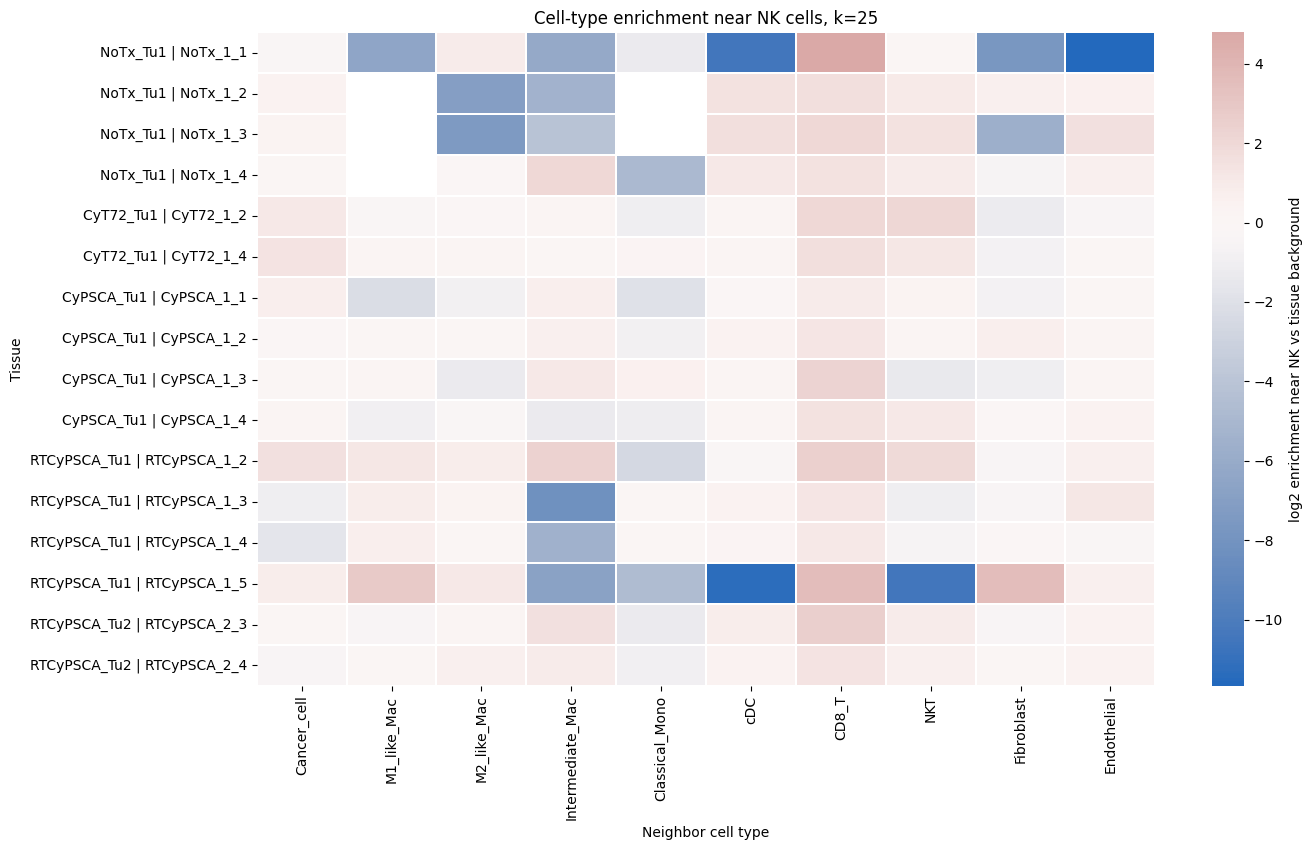

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/NK_neighborhood_enrichment_heatmap_per_tissue.png


In [14]:
heatmap_targets = [
    x for x in focus_targets
    if x in nk_neighbor_summary["target_cell_type"].astype(str).unique()
]

heatmap_df = nk_neighbor_summary.loc[
    nk_neighbor_summary["target_cell_type"].astype(str).isin(heatmap_targets)
].copy()

heatmap_df["tissue_display"] = (
    heatmap_df["treatment"].astype(str)
    + " | "
    + heatmap_df["tissue"].astype(str)
)

row_order = (
    heatmap_df[["tissue_display", "treatment", "tissue"]]
    .drop_duplicates()
    .assign(
        treatment_order=lambda x: x["treatment"].map({v: i for i, v in enumerate(plot_order)})
    )
    .sort_values(["treatment_order", "tissue"])
    ["tissue_display"]
    .tolist()
)

heat = (
    heatmap_df
    .pivot_table(
        index="tissue_display",
        columns="target_cell_type",
        values="enrichment_log2",
        aggfunc="mean"
    )
    .reindex(row_order)
    .reindex(columns=heatmap_targets)
)

plt.figure(figsize=(1.0 * len(heatmap_targets) + 4, 0.35 * len(heat) + 3))
sns.heatmap(
    heat,
    center=0,
    cmap="vlag",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "log2 enrichment near NK vs tissue background"}
)

plt.xlabel("Neighbor cell type")
plt.ylabel("Tissue")
plt.title(f"Cell-type enrichment near NK cells, k={k_neighbors}")
plt.tight_layout()

outfile = outdir / "NK_neighborhood_enrichment_heatmap_per_tissue.png"
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {outfile}")

# Visualization 2: treatment-level dot plot

Dot size = mean fraction of NK-neighborhood cells belonging to that target cell type.  
Dot color = enrichment/depletion relative to whole-tissue background composition.

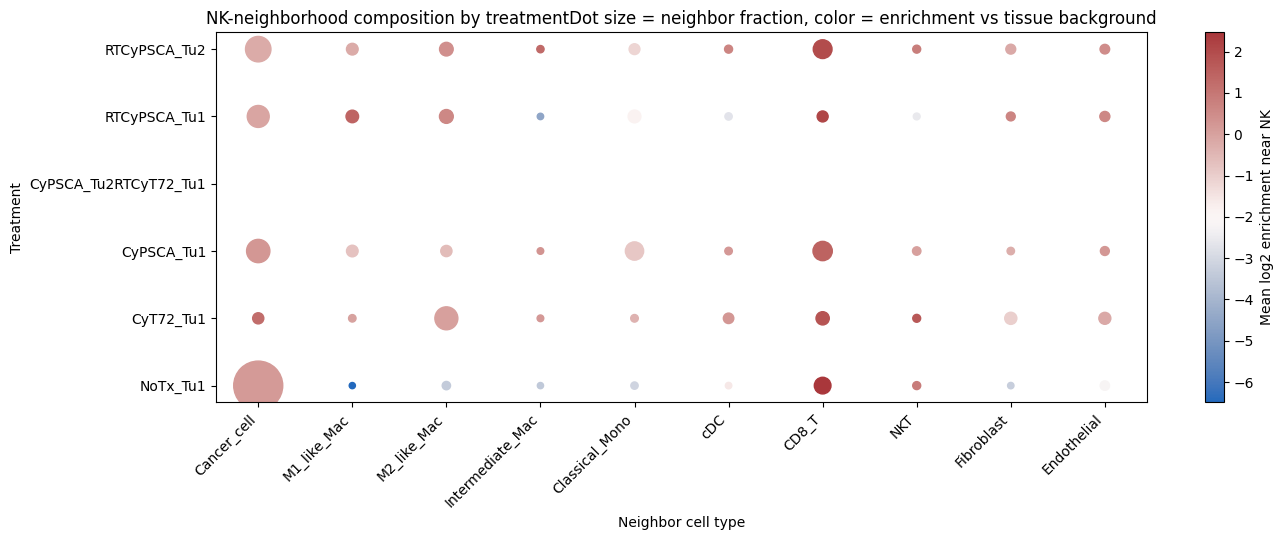

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/NK_neighborhood_treatment_dotplot.png


In [16]:
dot_df = (
    nk_neighbor_summary
    .loc[nk_neighbor_summary["target_cell_type"].astype(str).isin(heatmap_targets)]
    .groupby(["treatment", "target_cell_type"], observed=True)
    .agg(
        mean_neighbor_fraction=("neighbor_fraction", "mean"),
        mean_anchor_prevalence=("anchor_prevalence", "mean"),
        mean_enrichment_log2=("enrichment_log2", "mean"),
        n_tissues=("tissue", "nunique"),
    )
    .reset_index()
)

dot_df["treatment"] = pd.Categorical(dot_df["treatment"], categories=plot_order, ordered=True)
dot_df["target_cell_type"] = pd.Categorical(dot_df["target_cell_type"], categories=heatmap_targets, ordered=True)

plt.figure(figsize=(1.0 * len(heatmap_targets) + 4, 5.5))

scatter = plt.scatter(
    x=dot_df["target_cell_type"].cat.codes,
    y=dot_df["treatment"].cat.codes,
    s=dot_df["mean_neighbor_fraction"] * 2500 + 20,
    c=dot_df["mean_enrichment_log2"],
    cmap="vlag",
)

plt.colorbar(scatter, label="Mean log2 enrichment near NK")
plt.xticks(
    ticks=range(len(heatmap_targets)),
    labels=heatmap_targets,
    rotation=45,
    ha="right"
)
plt.yticks(
    ticks=range(len(plot_order)),
    labels=plot_order
)
plt.xlabel("Neighbor cell type")
plt.ylabel("Treatment")
plt.title(
    "NK-neighborhood composition by treatment"
    "Dot size = neighbor fraction, color = enrichment vs tissue background"
)
plt.tight_layout()

outfile = outdir / "NK_neighborhood_treatment_dotplot.png"
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {outfile}")

# Visualization 3: focused treatment comparisons

These plots are good for specific biological questions, such as whether NK cells are enriched near cancer cells, macrophages, cDCs, or other cytotoxic lymphocytes.

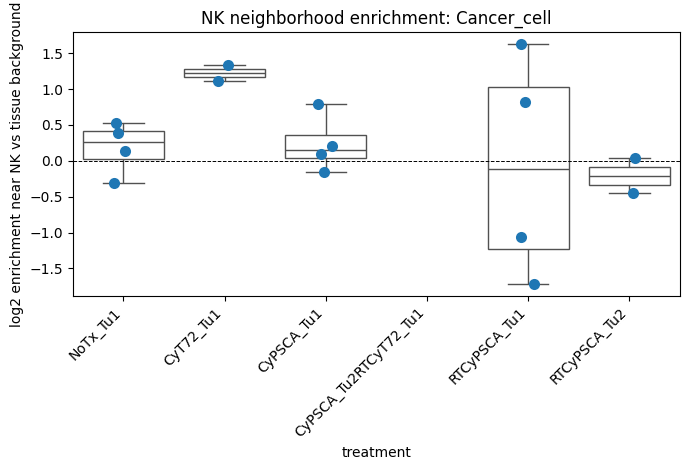

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/NK_neighborhood_enrichment_Cancer_cell.png


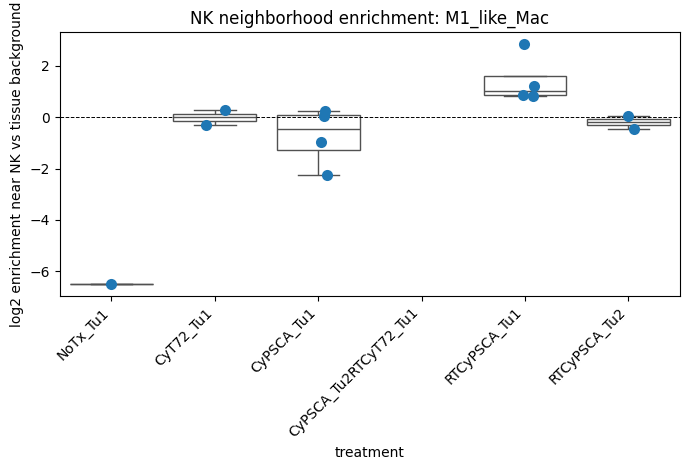

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/NK_neighborhood_enrichment_M1_like_Mac.png


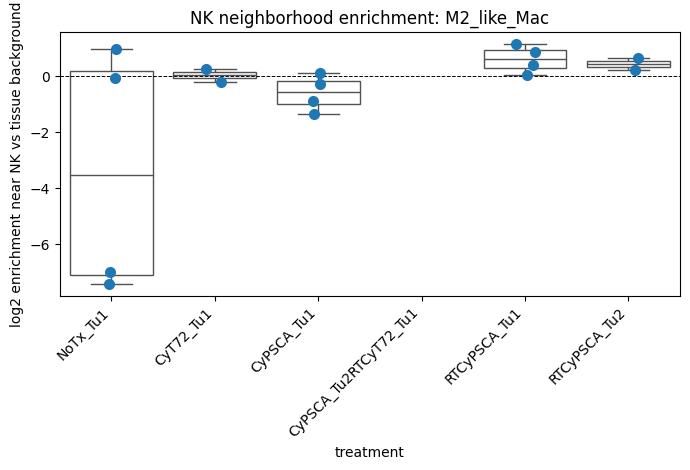

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/NK_neighborhood_enrichment_M2_like_Mac.png


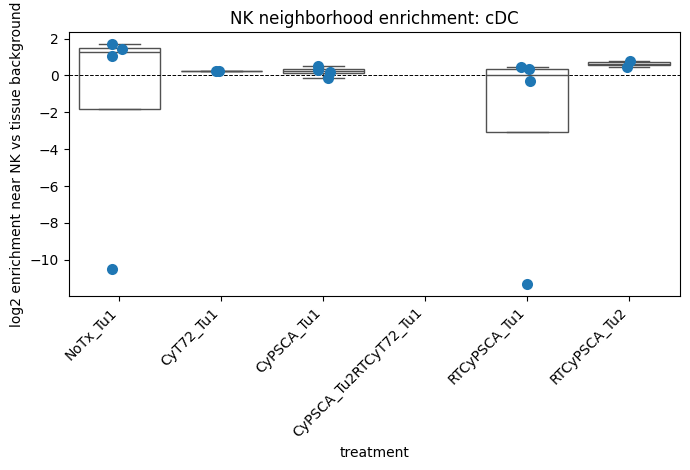

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/NK_neighborhood_enrichment_cDC.png


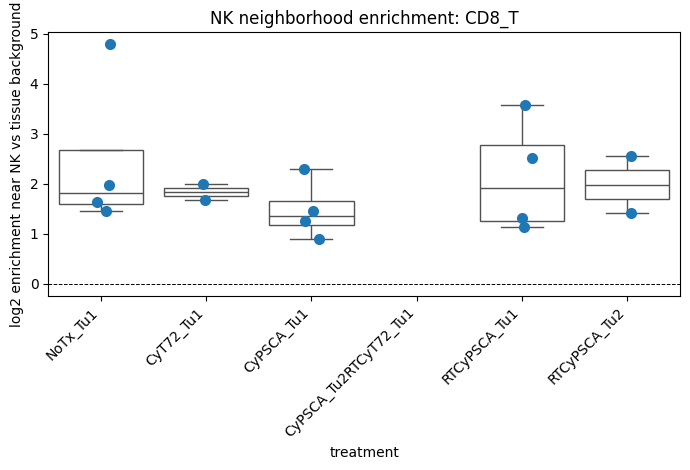

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/NK_neighborhood_enrichment_CD8_T.png


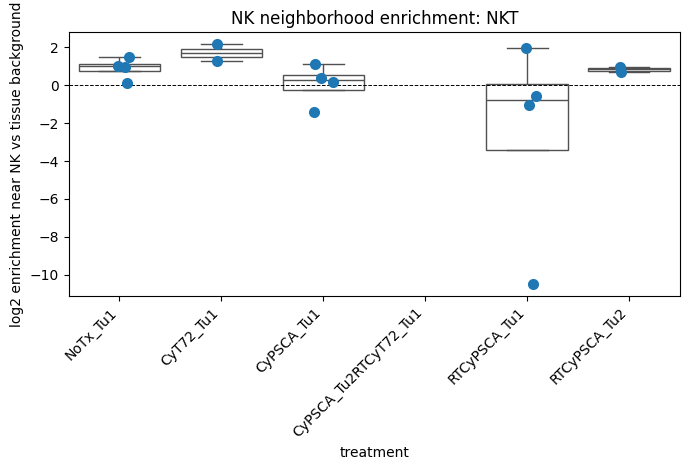

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/NK_neighborhood_enrichment_NKT.png


In [17]:
key_targets = [
    "Cancer_cell",
    "M1_like_Mac",
    "M2_like_Mac",
    "cDC",
    "CD8_T",
    "NK",
    "NKT",
]

key_targets = [
    x for x in key_targets
    if x in nk_neighbor_summary["target_cell_type"].astype(str).unique()
]

metric_to_plot = "enrichment_log2"

for target in key_targets:
    plot_df = nk_neighbor_summary.loc[
        nk_neighbor_summary["target_cell_type"].astype(str).eq(target)
        & nk_neighbor_summary["treatment"].isin(plot_order)
    ].copy()

    plt.figure(figsize=(7, 4.8))

    sns.stripplot(
        data=plot_df,
        x="treatment",
        y=metric_to_plot,
        order=plot_order,
        size=8,
        jitter=True
    )

    sns.boxplot(
        data=plot_df,
        x="treatment",
        y=metric_to_plot,
        order=plot_order,
        showfliers=False,
        boxprops={"facecolor": "none"}
    )

    plt.axhline(0, color="black", lw=0.7, ls="--")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("log2 enrichment near NK vs tissue background")
    plt.title(f"NK neighborhood enrichment: {target}")
    plt.tight_layout()

    outfile = outdir / f"NK_neighborhood_enrichment_{target}.png"
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {outfile}")

In [ ]:
# Heatmap: mean Moran's I per pathway across tissues, by treatment.
# Edit `heatmap_treatments` to change which conditions are shown.
heatmap_treatments = ["CyPSCA_Tu1", "RTCyPSCA_Tu1", "RTCyPSCA_Tu2"]

heatmap_df = (
    moran_df.loc[
        moran_df["treatment"].isin(heatmap_treatments)
        & moran_df["score_col"].isin(moran_score_cols)
    ]
    .groupby(["score_col", "treatment"], observed=True)["I"]
    .mean()
    .unstack("treatment")
    .reindex(index=moran_score_cols, columns=heatmap_treatments)
)

display(heatmap_df)

fig, ax = plt.subplots(figsize=(1.6 * len(heatmap_treatments) + 2, 0.55 * len(moran_score_cols) + 1.5))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    cbar_kws={"label": "Mean Moran's I"},
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Mean Moran's I across tissues")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

treatments_tag = "_".join(heatmap_treatments)
outfile = outdir / f"moranI_mean_heatmap_{treatments_tag}.png"
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {outfile}")


# Visualization 4: labeled dot plot for sample identity

Use this to identify which tissue corresponds to each dot.

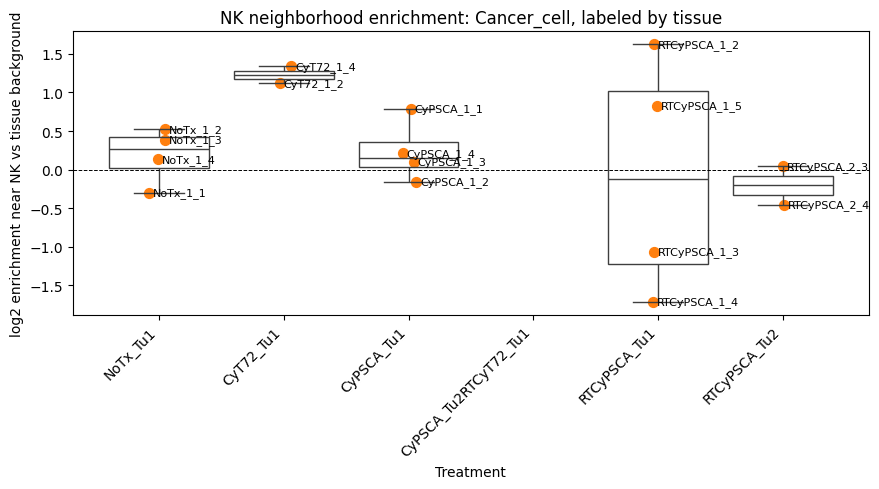

In [18]:
target_to_label = "Cancer_cell"
metric_to_plot = "enrichment_log2"

plot_df = nk_neighbor_summary.loc[
    nk_neighbor_summary["target_cell_type"].astype(str).eq(target_to_label)
    & nk_neighbor_summary["treatment"].isin(plot_order)
].copy()

rng = np.random.default_rng(7)
x_map = {t: i for i, t in enumerate(plot_order)}
plot_df["x_jitter"] = (
    plot_df["treatment"].map(x_map).astype(float)
    + rng.uniform(-0.08, 0.08, size=plot_df.shape[0])
)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=plot_df,
    x="treatment",
    y=metric_to_plot,
    order=plot_order,
    showfliers=False,
    boxprops={"facecolor": "none"}
)

plt.scatter(
    plot_df["x_jitter"],
    plot_df[metric_to_plot],
    s=50
)

for _, row in plot_df.iterrows():
    plt.text(
        row["x_jitter"] + 0.03,
        row[metric_to_plot],
        row["tissue"],
        fontsize=8,
        va="center"
    )

plt.axhline(0, color="black", lw=0.7, ls="--")
plt.xticks(
    ticks=range(len(plot_order)),
    labels=plot_order,
    rotation=45,
    ha="right"
)

plt.ylabel("log2 enrichment near NK vs tissue background")
plt.xlabel("Treatment")
plt.title(f"NK neighborhood enrichment: {target_to_label}, labeled by tissue")
plt.tight_layout()
plt.show()

# Visualization 5: spatial maps of NK cells and selected neighbors

This makes a simple coordinate-based spatial map without relying on SpatialData image rendering.

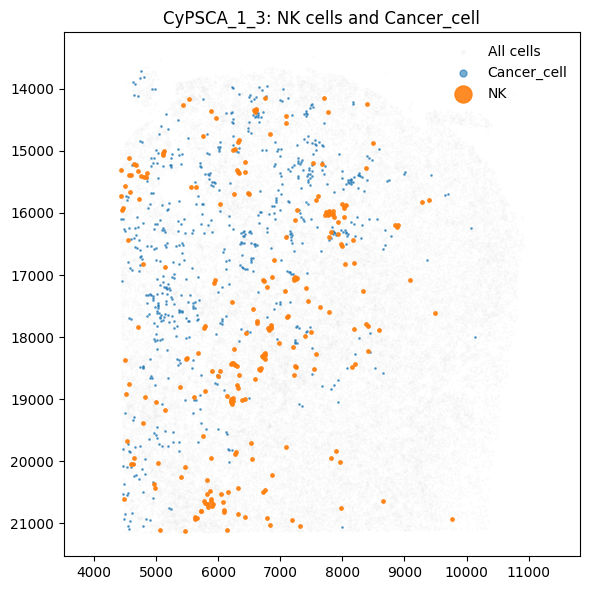

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/spatial_map_CyPSCA_1_3_NK_Cancer_cell.png


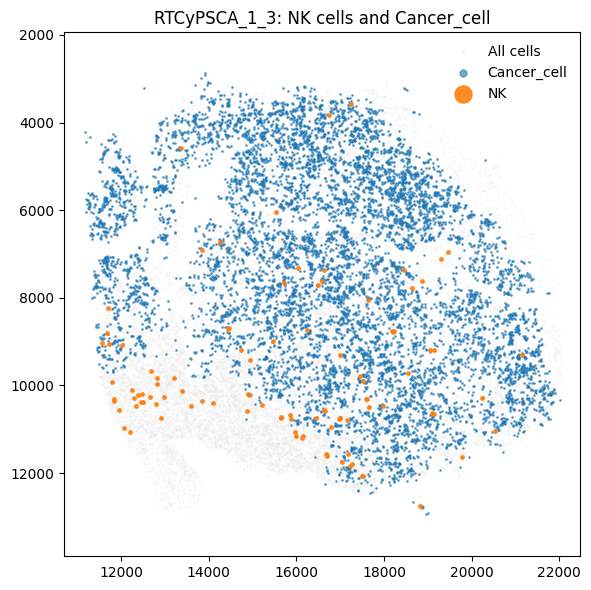

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/spatial_map_RTCyPSCA_1_3_NK_Cancer_cell.png


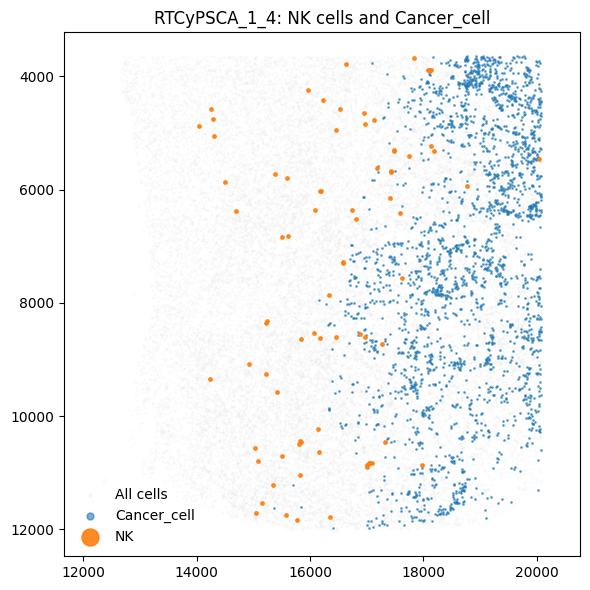

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/spatial_map_RTCyPSCA_1_4_NK_Cancer_cell.png


In [19]:
example_tissues = [
    "CyPSCA_1_3",
    "RTCyPSCA_1_3",
    "RTCyPSCA_1_4",
]

target_to_show = "Cancer_cell"

for tissue in example_tissues:
    tissue_mask = adata.obs[sample_col].astype(str).eq(tissue).values

    if tissue_mask.sum() == 0:
        print(f"Skipping {tissue}: not found.")
        continue

    obs_t = adata.obs.loc[tissue_mask].copy()
    coords_t = adata.obsm["spatial"][tissue_mask]
    labels_t = obs_t[celltype_col].astype(str).values

    nk_mask = labels_t == "NK"
    target_mask = labels_t == target_to_show

    # Downsample background for speed/readability.
    rng = np.random.default_rng(7)
    all_idx = np.arange(coords_t.shape[0])
    max_bg = 30000

    if len(all_idx) > max_bg:
        bg_idx = rng.choice(all_idx, size=max_bg, replace=False)
    else:
        bg_idx = all_idx

    plt.figure(figsize=(6, 6))

    plt.scatter(
        coords_t[bg_idx, 0],
        coords_t[bg_idx, 1],
        s=0.2,
        alpha=0.15,
        color="lightgrey",
        label="All cells"
    )

    plt.scatter(
        coords_t[target_mask, 0],
        coords_t[target_mask, 1],
        s=1.0,
        alpha=0.6,
        label=target_to_show
    )

    plt.scatter(
        coords_t[nk_mask, 0],
        coords_t[nk_mask, 1],
        s=6,
        alpha=0.9,
        label="NK"
    )

    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.title(f"{tissue}: NK cells and {target_to_show}")
    plt.legend(markerscale=5, frameon=False)
    plt.tight_layout()

    outfile = outdir / f"spatial_map_{tissue}_NK_{target_to_show}.png"
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {outfile}")

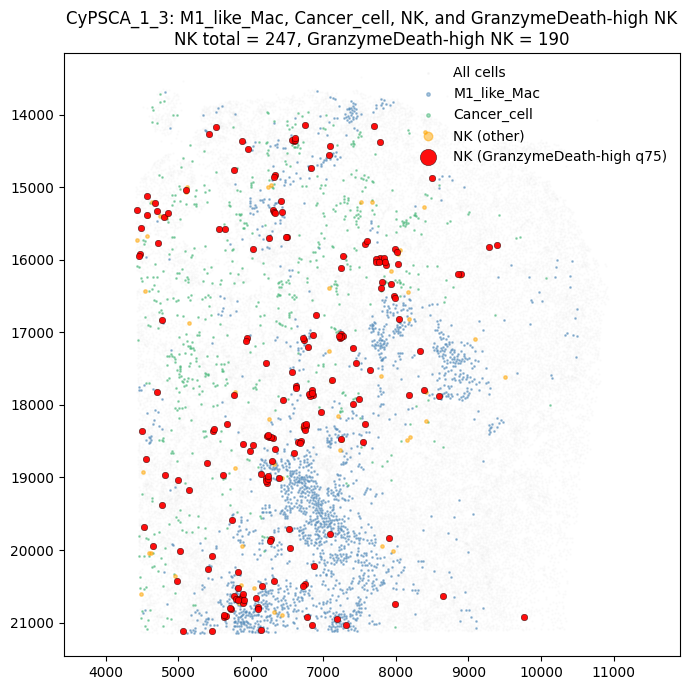

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/spatial_map_CyPSCA_1_3_HighGranzymeNK_M1_like_Mac_Cancer_cell.png


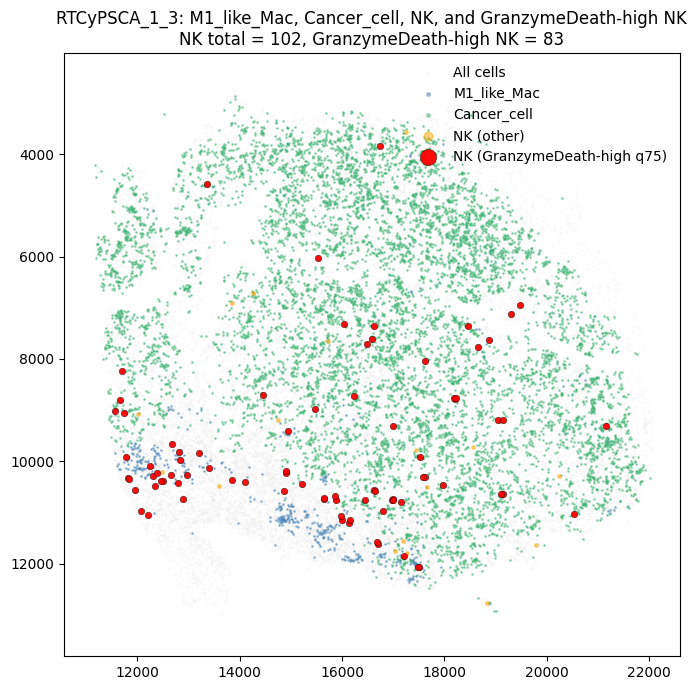

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/spatial_map_RTCyPSCA_1_3_HighGranzymeNK_M1_like_Mac_Cancer_cell.png


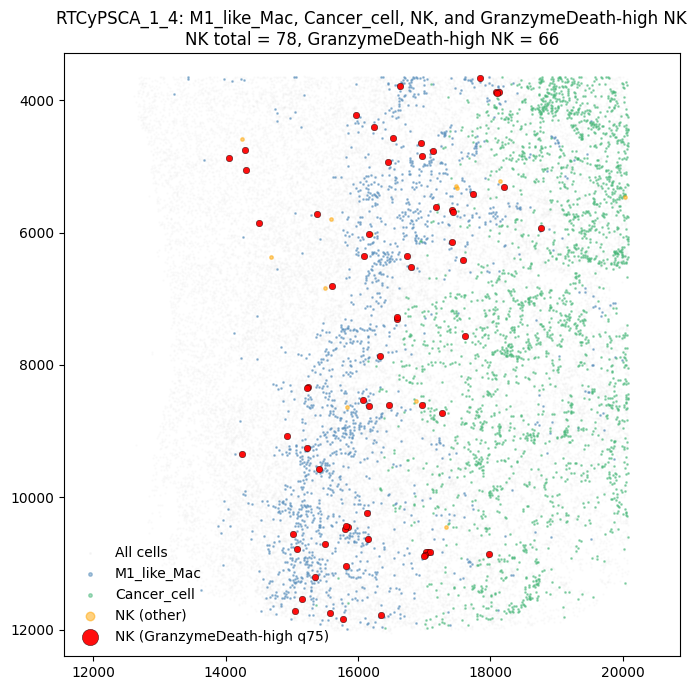

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/spatial_map_RTCyPSCA_1_4_HighGranzymeNK_M1_like_Mac_Cancer_cell.png


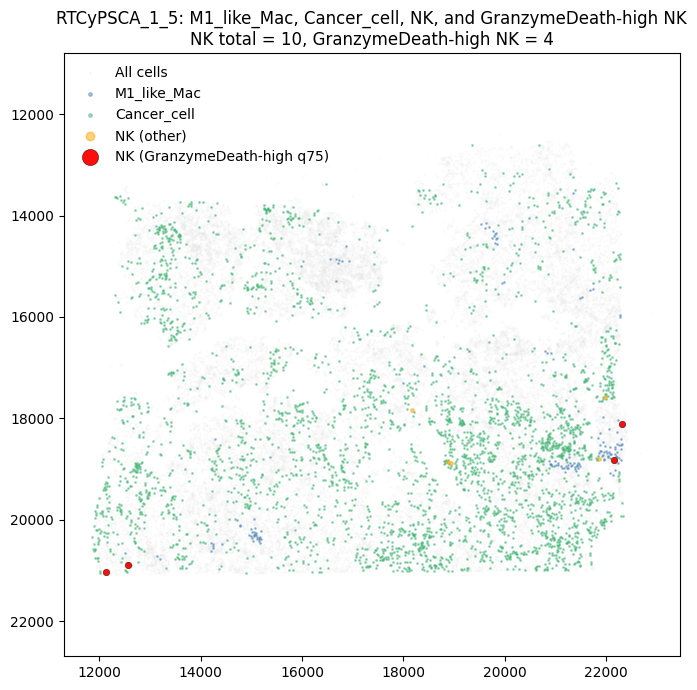

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/spatial_map_RTCyPSCA_1_5_HighGranzymeNK_M1_like_Mac_Cancer_cell.png


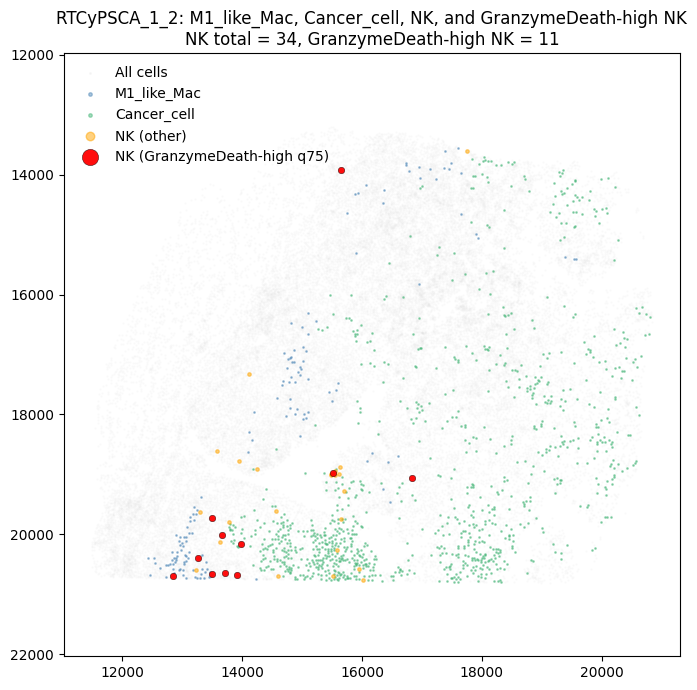

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/spatial_map_RTCyPSCA_1_2_HighGranzymeNK_M1_like_Mac_Cancer_cell.png


In [33]:
example_tissues = [
    "CyPSCA_1_3",
    "RTCyPSCA_1_3",
    "RTCyPSCA_1_4",
    "RTCyPSCA_1_5",
    "RTCyPSCA_1_2",
]

# Accepts a single string or a list of cell-type names.
target_to_show = ["M1_like_Mac", "Cancer_cell"]
high_nk_col = "NK_GranzymeDeath_q75_high"  # swap to q90 for the top 10%

# Normalize to a list of unique entries, preserving order.
if isinstance(target_to_show, str):
    targets = [target_to_show]
else:
    targets = list(dict.fromkeys(target_to_show))

# Color per target. Edit/extend here to pin specific colors to specific cell types.
target_palette = [
    "steelblue", "mediumseagreen", "mediumpurple",
    "darkcyan", "slateblue", "goldenrod",
]
target_colors = {t: target_palette[i % len(target_palette)] for i, t in enumerate(targets)}

for tissue in example_tissues:
    tissue_mask = adata.obs[sample_col].astype(str).eq(tissue).values

    if tissue_mask.sum() == 0:
        print(f"Skipping {tissue}: not found.")
        continue

    obs_t = adata.obs.loc[tissue_mask].copy()
    coords_t = adata.obsm["spatial"][tissue_mask]
    labels_t = obs_t[celltype_col].astype(str).values

    nk_mask = labels_t == "NK"
    high_nk_mask = obs_t[high_nk_col].values.astype(bool)

    rng = np.random.default_rng(7)
    all_idx = np.arange(coords_t.shape[0])
    max_bg = 30000
    bg_idx = rng.choice(all_idx, size=max_bg, replace=False) if len(all_idx) > max_bg else all_idx

    plt.figure(figsize=(7, 7))

    plt.scatter(
        coords_t[bg_idx, 0], coords_t[bg_idx, 1],
        s=0.2, alpha=0.15, color="lightgrey", label="All cells",
    )

    # Plot each target cell type as its own layer so it gets a distinct color + legend entry.
    for t in targets:
        target_mask = labels_t == t
        if not target_mask.any():
            print(f"  {tissue}: no cells labeled {t}, skipping that layer.")
            continue
        plt.scatter(
            coords_t[target_mask, 0], coords_t[target_mask, 1],
            s=1.0, alpha=0.45, color=target_colors[t], label=t,
        )

    # All NK — faint, small
    plt.scatter(
        coords_t[nk_mask & ~high_nk_mask, 0],
        coords_t[nk_mask & ~high_nk_mask, 1],
        s=6, alpha=0.5, color="orange", label="NK (other)",
    )

    # GranzymeDeath-high NK — large, prominent, outlined
    plt.scatter(
        coords_t[high_nk_mask, 0], coords_t[high_nk_mask, 1],
        s=22, alpha=0.95, color="red",
        edgecolors="black", linewidths=0.3,
        label="NK (GranzymeDeath-high q75)",
    )

    plt.gca().invert_yaxis()
    plt.axis("equal")

    n_all_nk = int(nk_mask.sum())
    n_high_nk = int(high_nk_mask.sum())
    targets_label = ", ".join(targets)
    plt.title(
        f"{tissue}: {targets_label}, NK, and GranzymeDeath-high NK\n"
        f"NK total = {n_all_nk}, GranzymeDeath-high NK = {n_high_nk}"
    )
    plt.legend(markerscale=2.5, frameon=False, loc="best")
    plt.tight_layout()

    targets_filename = "_".join(targets)
    outfile = outdir / f"spatial_map_{tissue}_HighGranzymeNK_{targets_filename}.png"
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {outfile}")


# Optional: GranzymeDeath-high NK neighborhood analysis

This repeats the neighborhood analysis using only NK cells above the global NK-specific q75 for the curated GO GranzymeDeath pathway.

In [20]:
run_high_granzyme_nk_analysis = True

if run_high_granzyme_nk_analysis and "NK_GranzymeDeath_q75_high" not in adata.obs.columns:
    raise ValueError(
        "NK_GranzymeDeath_q75_high not found. "
        "Run the optional normalization/scoring section first."
    )

In [21]:
high_nk_neighbor_rows = []

if run_high_granzyme_nk_analysis:
    for tissue in analysis_tissues:
        print(f"\nProcessing tissue: {tissue}")

        tissue_mask = adata.obs[sample_col].astype(str).eq(tissue).values
        obs_t = adata.obs.loc[tissue_mask].copy()
        coords_t = adata.obsm["spatial"][tissue_mask]

        labels_t = obs_t[celltype_col].astype(str).values
        treatment_t = obs_t[condition_col].astype(str).iloc[0]
        condition_t = obs_t["condition"].astype(str).iloc[0]
        tumor_loc_t = obs_t["tumor_loc"].astype(str).iloc[0]
        replicate_t = obs_t["replicate_num"].astype(str).iloc[0]

        anchor_mask_t = obs_t["NK_GranzymeDeath_q75_high"].values.astype(bool)
        anchor_local_idx = np.where(anchor_mask_t)[0]

        n_cells_t = obs_t.shape[0]
        n_anchor_t = len(anchor_local_idx)

        print(f"  total cells: {n_cells_t:,}")
        print(f"  GranzymeDeath-high NK anchors: {n_anchor_t:,}")

        if n_anchor_t < min_anchor_cells:
            print(f"  Skipping: fewer than {min_anchor_cells} high-granzyme NK anchors.")
            continue

        n_query_neighbors = min(k_neighbors + 1, n_cells_t)

        nn = NearestNeighbors(
            n_neighbors=n_query_neighbors,
            algorithm="auto"
        )
        nn.fit(coords_t)

        neighbor_idx_raw = nn.kneighbors(
            coords_t[anchor_local_idx],
            return_distance=False
        )

        neighbor_idx_clean = []

        for row_i, neighs in enumerate(neighbor_idx_raw):
            self_idx = anchor_local_idx[row_i]
            clean = [idx for idx in neighs if idx != self_idx]
            clean = clean[:k_neighbors]
            neighbor_idx_clean.append(clean)

        neighbor_idx_clean = np.array(neighbor_idx_clean, dtype=int)
        neighbor_labels = labels_t[neighbor_idx_clean.ravel()]

        background_counts = pd.Series(labels_t).value_counts()
        background_fraction = background_counts / background_counts.sum()

        neighbor_counts = pd.Series(neighbor_labels).value_counts()
        neighbor_fraction = neighbor_counts / neighbor_counts.sum()

        neighbor_label_matrix = labels_t[neighbor_idx_clean]
        all_labels_this_tissue = sorted(set(labels_t).union(set(neighbor_labels)))

        for target in all_labels_this_tissue:
            n_neighbor_target = int((neighbor_labels == target).sum())
            frac_neighbor_target = float(neighbor_fraction.get(target, 0.0))
            frac_background_target = float(background_fraction.get(target, 0.0))

            anchor_has_target = (neighbor_label_matrix == target).any(axis=1)
            anchor_prevalence = float(anchor_has_target.mean())

            eps = 1e-6
            enrichment_log2 = np.log2(
                (frac_neighbor_target + eps) /
                (frac_background_target + eps)
            )

            high_nk_neighbor_rows.append({
                "tissue": tissue,
                "condition": condition_t,
                "tumor_loc": tumor_loc_t,
                "replicate_num": replicate_t,
                "treatment": treatment_t,
                "anchor_cell_type": "NK_GranzymeDeath_q75_high",
                "target_cell_type": target,
                "n_cells_tissue": n_cells_t,
                "n_anchor_cells": n_anchor_t,
                "k_neighbors": k_neighbors,
                "n_neighbor_slots": int(n_anchor_t * k_neighbors),
                "n_neighbor_target": n_neighbor_target,
                "neighbor_fraction": frac_neighbor_target,
                "anchor_prevalence": anchor_prevalence,
                "background_fraction": frac_background_target,
                "enrichment_log2": enrichment_log2,
            })

high_nk_neighbor_summary = pd.DataFrame(high_nk_neighbor_rows)

display(high_nk_neighbor_summary.head())

high_nk_neighbor_summary.to_csv(
    outdir / "HighGranzyme_NK_neighborhood_celltype_summary_per_tissue.csv",
    index=False,
)

print(f"Saved: {outdir / 'HighGranzyme_NK_neighborhood_celltype_summary_per_tissue.csv'}")


Processing tissue: CyPSCA_1_1
  total cells: 108,895
  GranzymeDeath-high NK anchors: 294

Processing tissue: CyPSCA_1_2
  total cells: 55,540
  GranzymeDeath-high NK anchors: 309

Processing tissue: CyPSCA_1_3
  total cells: 33,085
  GranzymeDeath-high NK anchors: 190

Processing tissue: CyPSCA_1_4
  total cells: 27,025
  GranzymeDeath-high NK anchors: 70

Processing tissue: CyT72_1_2
  total cells: 34,108
  GranzymeDeath-high NK anchors: 94

Processing tissue: CyT72_1_4
  total cells: 49,785
  GranzymeDeath-high NK anchors: 203

Processing tissue: NoTx_1_1
  total cells: 44,929
  GranzymeDeath-high NK anchors: 1
  Skipping: fewer than 10 high-granzyme NK anchors.

Processing tissue: NoTx_1_2
  total cells: 23,792
  GranzymeDeath-high NK anchors: 2
  Skipping: fewer than 10 high-granzyme NK anchors.

Processing tissue: NoTx_1_3
  total cells: 59,018
  GranzymeDeath-high NK anchors: 32

Processing tissue: NoTx_1_4
  total cells: 34,688
  GranzymeDeath-high NK anchors: 31

Processing t

,tissue,condition,tumor_loc,replicate_num,treatment,anchor_cell_type,target_cell_type,n_cells_tissue,n_anchor_cells,k_neighbors,n_neighbor_slots,n_neighbor_target,neighbor_fraction,anchor_prevalence,background_fraction,enrichment_log2
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,NK_GranzymeDeath_q75_high,B,108895,294,25,7350,153,0.020816,0.377551,0.020671,0.010087
1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,NK_GranzymeDeath_q75_high,CD4_T,108895,294,25,7350,89,0.012109,0.214286,0.011001,0.138359
2,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,NK_GranzymeDeath_q75_high,CD8_T,108895,294,25,7350,442,0.060136,0.625850,0.049102,0.292433
3,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,NK_GranzymeDeath_q75_high,Cancer_cell,108895,294,25,7350,546,0.074286,0.537415,0.082850,-0.157423
4,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,NK_GranzymeDeath_q75_high,Classical_Mono,108895,294,25,7350,242,0.032925,0.292517,0.041085,-0.319428


Saved: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/HighGranzyme_NK_neighborhood_celltype_summary_per_tissue.csv


## Compare all NK vs GranzymeDeath-high NK neighborhoods

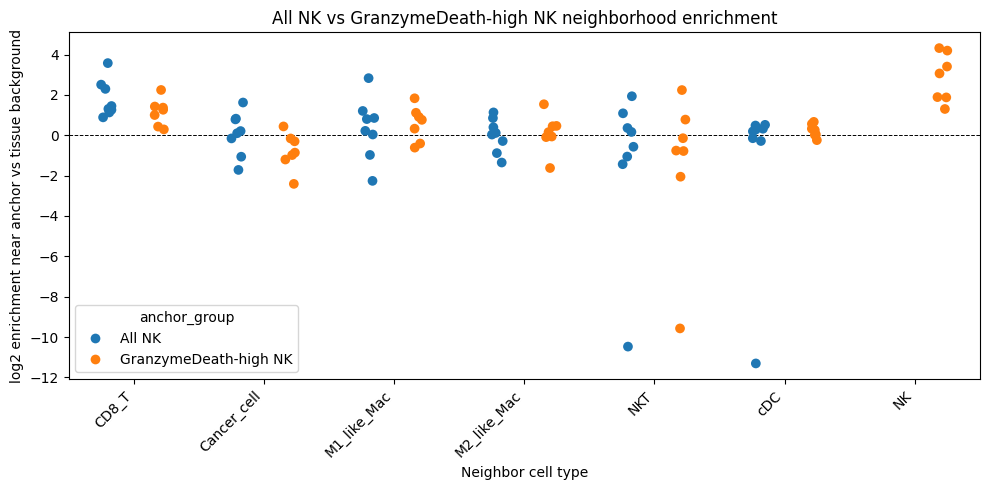

In [22]:
if run_high_granzyme_nk_analysis and len(high_nk_neighbor_summary) > 0:
    all_nk_tmp = nk_neighbor_summary.copy()
    all_nk_tmp["anchor_group"] = "All NK"

    high_nk_tmp = high_nk_neighbor_summary.copy()
    high_nk_tmp["anchor_group"] = "GranzymeDeath-high NK"

    anchor_compare_df = pd.concat(
        [all_nk_tmp, high_nk_tmp],
        ignore_index=True,
        sort=False,
    )

    plot_targets = [
        "Cancer_cell",
        "M1_like_Mac",
        "M2_like_Mac",
        "cDC",
        "CD8_T",
        "NK",
        "NKT",
    ]

    plot_targets = [
        x for x in plot_targets
        if x in anchor_compare_df["target_cell_type"].astype(str).unique()
    ]

    plot_df = anchor_compare_df.loc[
        anchor_compare_df["target_cell_type"].astype(str).isin(plot_targets)
        & anchor_compare_df["treatment"].isin(["CyPSCA_Tu1", "RTCyPSCA_Tu1"])
    ].copy()

    plt.figure(figsize=(10, 5))

    sns.stripplot(
        data=plot_df,
        x="target_cell_type",
        y="enrichment_log2",
        hue="anchor_group",
        dodge=True,
        size=7,
    )

    plt.axhline(0, color="black", lw=0.7, ls="--")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("log2 enrichment near anchor vs tissue background")
    plt.xlabel("Neighbor cell type")
    plt.title("All NK vs GranzymeDeath-high NK neighborhood enrichment")
    plt.tight_layout()
    plt.show()
else:
    print("No high-granzyme NK neighborhood summary available.")

## Save final output manifest

In [23]:
summary_files = {
    "nk_neighbor_summary": outdir / "NK_neighborhood_celltype_summary_per_tissue.csv",
    "nk_neighbor_stats": outdir / "NK_neighborhood_stats_RTCyPSCA_Tu1_vs_CyPSCA_Tu1.csv",
}

if "high_nk_neighbor_summary" in globals() and len(high_nk_neighbor_summary) > 0:
    summary_files["high_granzyme_nk_neighbor_summary"] = (
        outdir / "HighGranzyme_NK_neighborhood_celltype_summary_per_tissue.csv"
    )

print("Output files:")
for name, path in summary_files.items():
    print(f"{name}: {path}")

Output files:
nk_neighbor_summary: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/NK_neighborhood_celltype_summary_per_tissue.csv
nk_neighbor_stats: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/NK_neighborhood_stats_RTCyPSCA_Tu1_vs_CyPSCA_Tu1.csv
high_granzyme_nk_neighbor_summary: /coh_labs/yunroseli/Jona/CAR-T/results/nk_neighborhood_analysis/HighGranzyme_NK_neighborhood_celltype_summary_per_tissue.csv


# Interpretation guide

The strongest spatial claims will come from the enrichment-based metrics, not raw neighbor fractions alone.

Use these outputs as follows:

| Output | Main use |
|---|---|
| `neighbor_fraction` | Cell-type composition around NK cells |
| `anchor_prevalence` | Fraction of NK cells with at least one neighbor of a given cell type |
| `background_fraction` | Tissue-wide abundance of that cell type |
| `enrichment_log2` | Whether a cell type is specifically enriched near NK cells beyond tissue composition |

Useful biological readings:

- If `Cancer_cell` has high `neighbor_fraction` near NK cells, NK cells are often near tumor cells.
- If `Cancer_cell` also has high positive `enrichment_log2`, NK cells are preferentially near tumor cells beyond what would be expected from tumor-cell abundance.
- If `cDC`, `M1_like_Mac`, or `M2_like_Mac` are enriched near high-granzyme NK cells, that suggests a possible APC–NK spatial niche.
- If `NK` or `NKT` are enriched near NK cells, this suggests cytotoxic-cell clustering.
- If `RTCyPSCA_Tu1` differs from `CyPSCA_Tu1`, interpret the result at the tissue level because each point is one spatial sample.

# Exploring Death

In [38]:
search_terms = [
    "APOPT",
    "PROGRAMMED_CELL_DEATH",
    "DNA_DAMAGE",
    "P53",
    "PHAGOCYT",
    "EFFEROCYT",
    "ENGULFMENT",
    "CLEARANCE",
    "CELL_CORPSE",
    "NECRO",
]
# Load all pathway GMTs into all_gene_sets and gene_set_metadata
gmt_files = {
    "hallmark": pathway_dir / "mh.all.v2026.1.Mm.symbols.gmt",
    "reactome": pathway_dir / "m2.cp.reactome.v2026.1.Mm.symbols.gmt",
    "go_bp": pathway_dir / "m5.go.bp.v2026.1.Mm.symbols.gmt",
}

all_gene_sets = {}
gene_set_metadata_rows = []

for collection, gmt_path in gmt_files.items():
    if not gmt_path.exists():
        print(f"WARNING: missing GMT file for {collection}: {gmt_path}")
        continue

    with open(gmt_path, "r") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue

            gene_set_name = parts[0]
            description = parts[1]
            genes = parts[2:]

            all_gene_sets[gene_set_name] = genes

            gene_set_metadata_rows.append({
                "collection": collection,
                "gene_set": gene_set_name,
                "description": description,
                "n_genes": len(genes),
                "source_file": gmt_path.name,
            })

gene_set_metadata = pd.DataFrame(gene_set_metadata_rows)

print(f"Loaded {len(all_gene_sets):,} total gene sets.")
display(gene_set_metadata.head())

Loaded 9,164 total gene sets.


,collection,gene_set,description,n_genes,source_file
0,hallmark,HALLMARK_ADIPOGENESIS,https://www.gsea-msigdb.org/gsea/msigdb/mouse/...,200,mh.all.v2026.1.Mm.symbols.gmt
1,hallmark,HALLMARK_ALLOGRAFT_REJECTION,https://www.gsea-msigdb.org/gsea/msigdb/mouse/...,192,mh.all.v2026.1.Mm.symbols.gmt
2,hallmark,HALLMARK_ANDROGEN_RESPONSE,https://www.gsea-msigdb.org/gsea/msigdb/mouse/...,96,mh.all.v2026.1.Mm.symbols.gmt
3,hallmark,HALLMARK_ANGIOGENESIS,https://www.gsea-msigdb.org/gsea/msigdb/mouse/...,36,mh.all.v2026.1.Mm.symbols.gmt
4,hallmark,HALLMARK_APICAL_JUNCTION,https://www.gsea-msigdb.org/gsea/msigdb/mouse/...,199,mh.all.v2026.1.Mm.symbols.gmt


In [39]:
candidate_death_sets = (
    gene_set_metadata
    .loc[
        gene_set_metadata["gene_set"].str.contains(
            "|".join(search_terms),
            case=False,
            regex=True
        )
    ]
    .sort_values(["collection", "gene_set"])
)

display(
    candidate_death_sets[
        ["collection", "gene_set", "n_genes", "source_file"]
    ].head(200)
)

,collection,gene_set,n_genes,source_file
1551,go_bp,GOBP_AMYLOID_BETA_CLEARANCE,41,m5.go.bp.v2026.1.Mm.symbols.gmt
1552,go_bp,GOBP_AMYLOID_BETA_CLEARANCE_BY_CELLULAR_CATABO...,8,m5.go.bp.v2026.1.Mm.symbols.gmt
1553,go_bp,GOBP_AMYLOID_BETA_CLEARANCE_BY_TRANSCYTOSIS,7,m5.go.bp.v2026.1.Mm.symbols.gmt
1622,go_bp,GOBP_APOPTOTIC_CELL_CLEARANCE,40,m5.go.bp.v2026.1.Mm.symbols.gmt
1623,go_bp,GOBP_APOPTOTIC_CHROMOSOME_CONDENSATION,6,m5.go.bp.v2026.1.Mm.symbols.gmt
...,...,...,...,...
7488,go_bp,GOBP_REGULATION_OF_MYELOID_CELL_APOPTOTIC_PROCESS,32,m5.go.bp.v2026.1.Mm.symbols.gmt
7504,go_bp,GOBP_REGULATION_OF_NECROPTOTIC_PROCESS,24,m5.go.bp.v2026.1.Mm.symbols.gmt
7526,go_bp,GOBP_REGULATION_OF_NEUTROPHIL_APOPTOTIC_PROCESS,9,m5.go.bp.v2026.1.Mm.symbols.gmt
7578,go_bp,GOBP_REGULATION_OF_OXIDATIVE_STRESS_INDUCED_IN...,44,m5.go.bp.v2026.1.Mm.symbols.gmt


In [40]:
death_cleanup_pathway_panel = {
    # Cell death / apoptosis
    "ApoptoticSignaling_GO": "GOBP_APOPTOTIC_SIGNALING_PATHWAY",
    "ProgrammedCellDeath_GO": "GOBP_PROGRAMMED_CELL_DEATH",
    "PositiveRegApoptosis_GO": "GOBP_POSITIVE_REGULATION_OF_APOPTOTIC_PROCESS",

    # DNA damage / radiation stress
    "DNADamageResponse_GO": "GOBP_DNA_DAMAGE_RESPONSE",
    "P53MediatedDNADamage_GO": "GOBP_INTRINSIC_APOPTOTIC_SIGNALING_PATHWAY_BY_P53_CLASS_MEDIATOR",

    # Phagocytosis / dead-cell clearance
    "Phagocytosis_GO": "GOBP_PHAGOCYTOSIS",
    "Engulfment_GO": "GOBP_ENGULFMENT_OF_APOPTOTIC_CELL",
}

In [41]:
death_panel_check = []

for short_name, gene_set_name in death_cleanup_pathway_panel.items():
    death_panel_check.append({
        "short_name": short_name,
        "gene_set_name": gene_set_name,
        "found": gene_set_name in all_gene_sets,
        "n_genes": len(all_gene_sets[gene_set_name]) if gene_set_name in all_gene_sets else np.nan,
    })

death_panel_check_df = pd.DataFrame(death_panel_check)
display(death_panel_check_df)

,short_name,gene_set_name,found,n_genes
0,ApoptoticSignaling_GO,GOBP_APOPTOTIC_SIGNALING_PATHWAY,True,669.0
1,ProgrammedCellDeath_GO,GOBP_PROGRAMMED_CELL_DEATH,False,NaN
2,PositiveRegApoptosis_GO,GOBP_POSITIVE_REGULATION_OF_APOPTOTIC_PROCESS,False,NaN
3,DNADamageResponse_GO,GOBP_DNA_DAMAGE_RESPONSE,True,924.0
4,P53MediatedDNADamage_GO,GOBP_INTRINSIC_APOPTOTIC_SIGNALING_PATHWAY_BY_...,True,89.0
5,Phagocytosis_GO,GOBP_PHAGOCYTOSIS,True,248.0
6,Engulfment_GO,GOBP_ENGULFMENT_OF_APOPTOTIC_CELL,True,12.0


In [42]:
available_genes = set(adata.var_names.astype(str))

death_score_records = []

for short_name, gene_set_name in death_cleanup_pathway_panel.items():
    if gene_set_name not in all_gene_sets:
        print(f"Skipping missing pathway: {gene_set_name}")
        continue

    pathway_genes = all_gene_sets[gene_set_name]

    matched_genes = [g for g in pathway_genes if g in available_genes]
    missing_genes = [g for g in pathway_genes if g not in available_genes]

    score_col = f"{short_name}_score"

    print(f"\nScoring: {short_name}")
    print(f"  MSigDB pathway: {gene_set_name}")
    print(f"  pathway genes: {len(pathway_genes)}")
    print(f"  matched genes: {len(matched_genes)}")
    print(f"  missing genes: {len(missing_genes)}")

    if len(matched_genes) < 5:
        print(f"  WARNING: fewer than 5 matched genes. Skipping.")
        continue

    sc.tl.score_genes(
        adata,
        gene_list=matched_genes,
        score_name=score_col,
        use_raw=False
    )

    death_score_records.append({
        "short_name": short_name,
        "gene_set_name": gene_set_name,
        "score_col": score_col,
        "n_pathway_genes": len(pathway_genes),
        "n_matched_genes": len(matched_genes),
        "n_missing_genes": len(missing_genes),
        "matched_genes": ";".join(matched_genes),
        "missing_genes": ";".join(missing_genes),
    })

death_score_summary_df = pd.DataFrame(death_score_records)
display(death_score_summary_df)

death_score_cols = death_score_summary_df["score_col"].tolist()


Scoring: ApoptoticSignaling_GO
  MSigDB pathway: GOBP_APOPTOTIC_SIGNALING_PATHWAY
  pathway genes: 669
  matched genes: 638
  missing genes: 31
Skipping missing pathway: GOBP_PROGRAMMED_CELL_DEATH
Skipping missing pathway: GOBP_POSITIVE_REGULATION_OF_APOPTOTIC_PROCESS

Scoring: DNADamageResponse_GO
  MSigDB pathway: GOBP_DNA_DAMAGE_RESPONSE
  pathway genes: 924
  matched genes: 883
  missing genes: 41

Scoring: P53MediatedDNADamage_GO
  MSigDB pathway: GOBP_INTRINSIC_APOPTOTIC_SIGNALING_PATHWAY_BY_P53_CLASS_MEDIATOR
  pathway genes: 89
  matched genes: 83
  missing genes: 6

Scoring: Phagocytosis_GO
  MSigDB pathway: GOBP_PHAGOCYTOSIS
  pathway genes: 248
  matched genes: 241
  missing genes: 7

Scoring: Engulfment_GO
  MSigDB pathway: GOBP_ENGULFMENT_OF_APOPTOTIC_CELL
  pathway genes: 12
  matched genes: 12
  missing genes: 0


,short_name,gene_set_name,score_col,n_pathway_genes,n_matched_genes,n_missing_genes,matched_genes,missing_genes
0,ApoptoticSignaling_GO,GOBP_APOPTOTIC_SIGNALING_PATHWAY,ApoptoticSignaling_GO_score,669,638,31,Aatf;Acaa2;Ackr3;Acsl5;Acvr1;Acvr1b;Acvr1c;Adc...,AY074887;Atp5if1;Bbln;Bcl2a1a;Bcl2a1c;Clec7a;C...
1,DNADamageResponse_GO,GOBP_DNA_DAMAGE_RESPONSE,DNADamageResponse_GO_score,924,883,41,Abl1;Abraxas1;Acd;Acer2;Ackr3;Actl6a;Actl6b;Ac...,4930447C04Rik;4931406C07Rik;Aars1;Actb;Adprs;B...
2,P53MediatedDNADamage_GO,GOBP_INTRINSIC_APOPTOTIC_SIGNALING_PATHWAY_BY_...,P53MediatedDNADamage_GO_score,89,83,6,Aen;Ankrd2;Armc10;Atad5;Bag6;Bax;Bbc3;Bcl2l12;...,Marchf7;Rpl26;Rps27l;Rps7;Rrp8;Ubb
3,Phagocytosis_GO,GOBP_PHAGOCYTOSIS,Phagocytosis_GO_score,248,241,7,Abca1;Abca7;Abl1;Abl2;Abr;Adgrb1;Adipoq;Ager;A...,4933434E20Rik;Bltp1;Clec7a;Klrh1;Timd5;Timd6;T...
4,Engulfment_GO,GOBP_ENGULFMENT_OF_APOPTOTIC_CELL,Engulfment_GO_score,12,12,0,Abca7;Adgrb1;Alox15;Becn1;Megf10;Rac1;Thbs1;Tr...,


In [43]:
from sklearn.neighbors import NearestNeighbors

anchor_col = "NK_GranzymeDeath_q75_high"
k_neighbors = 25

death_neighbor_rows = []

for tissue in analysis_tissues:
    print(f"\nProcessing tissue: {tissue}")

    tissue_mask = adata.obs["tissue"].astype(str).eq(tissue).values
    obs_t = adata.obs.loc[tissue_mask].copy()
    coords_t = adata.obsm["spatial"][tissue_mask]

    anchor_mask = obs_t[anchor_col].values.astype(bool)
    anchor_idx = np.where(anchor_mask)[0]

    if len(anchor_idx) < 10:
        print(f"  Skipping {tissue}: fewer than 10 high-granzyme NK cells.")
        continue

    n_query_neighbors = min(k_neighbors + 1, obs_t.shape[0])

    nn = NearestNeighbors(n_neighbors=n_query_neighbors)
    nn.fit(coords_t)

    neigh_idx_raw = nn.kneighbors(coords_t[anchor_idx], return_distance=False)

    neigh_idx_clean = []

    for i, neighs in enumerate(neigh_idx_raw):
        self_idx = anchor_idx[i]
        clean = [idx for idx in neighs if idx != self_idx]
        clean = clean[:k_neighbors]
        neigh_idx_clean.append(clean)

    neigh_idx_clean = np.array(neigh_idx_clean)

    neighbor_obs = obs_t.iloc[neigh_idx_clean.ravel()].copy()

    row = {
        "tissue": tissue,
        "condition": obs_t["condition"].iloc[0],
        "tumor_loc": obs_t["tumor_loc"].iloc[0],
        "replicate_num": obs_t["replicate_num"].iloc[0],
        "treatment": obs_t["treatment"].iloc[0],
        "n_high_granzyme_nk": len(anchor_idx),
        "n_neighbor_cells": neighbor_obs.shape[0],
    }

    # Mean pathway score in cells neighboring high-granzyme NK cells
    for score_col in death_score_cols:
        row[f"neighbor_mean_{score_col}"] = neighbor_obs[score_col].mean()
        row[f"neighbor_median_{score_col}"] = neighbor_obs[score_col].median()

    # Also summarize neighbor cell types
    row["neighbor_frac_cancer"] = (
        neighbor_obs["c2l_permissive"].astype(str).eq("Cancer_cell").mean()
    )
    row["neighbor_frac_m1_mac"] = (
        neighbor_obs["c2l_permissive"].astype(str).eq("M1_like_Mac").mean()
    )
    row["neighbor_frac_m2_mac"] = (
        neighbor_obs["c2l_permissive"].astype(str).eq("M2_like_Mac").mean()
    )
    row["neighbor_frac_any_mac"] = (
        neighbor_obs["c2l_permissive"].astype(str).isin([
            "M1_like_Mac",
            "M2_like_Mac",
            "Intermediate_Mac",
        ]).mean()
    )

    death_neighbor_rows.append(row)

death_neighbor_summary = pd.DataFrame(death_neighbor_rows)
display(death_neighbor_summary)


Processing tissue: CyPSCA_1_1

Processing tissue: CyPSCA_1_2

Processing tissue: CyPSCA_1_3

Processing tissue: CyPSCA_1_4

Processing tissue: CyT72_1_2

Processing tissue: CyT72_1_4

Processing tissue: NoTx_1_1
  Skipping NoTx_1_1: fewer than 10 high-granzyme NK cells.

Processing tissue: NoTx_1_2
  Skipping NoTx_1_2: fewer than 10 high-granzyme NK cells.

Processing tissue: NoTx_1_3

Processing tissue: NoTx_1_4

Processing tissue: RTCyPSCA_1_2

Processing tissue: RTCyPSCA_1_3

Processing tissue: RTCyPSCA_1_4

Processing tissue: RTCyPSCA_1_5
  Skipping RTCyPSCA_1_5: fewer than 10 high-granzyme NK cells.

Processing tissue: RTCyPSCA_2_3

Processing tissue: RTCyPSCA_2_4


,tissue,condition,tumor_loc,replicate_num,treatment,n_high_granzyme_nk,n_neighbor_cells,neighbor_mean_ApoptoticSignaling_GO_score,neighbor_median_ApoptoticSignaling_GO_score,neighbor_mean_DNADamageResponse_GO_score,...,neighbor_mean_P53MediatedDNADamage_GO_score,neighbor_median_P53MediatedDNADamage_GO_score,neighbor_mean_Phagocytosis_GO_score,neighbor_median_Phagocytosis_GO_score,neighbor_mean_Engulfment_GO_score,neighbor_median_Engulfment_GO_score,neighbor_frac_cancer,neighbor_frac_m1_mac,neighbor_frac_m2_mac,neighbor_frac_any_mac
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,294,7350,0.083795,0.083231,0.052318,...,0.143733,0.140788,0.075959,0.072740,-0.076798,-0.110327,0.074286,0.009388,0.004626,0.015646
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,309,7725,0.127567,0.128036,0.062312,...,0.199218,0.197592,0.148306,0.145491,-0.091196,-0.125856,0.122848,0.014110,0.010874,0.025372
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,190,4750,0.134857,0.134854,0.061229,...,0.206491,0.207995,0.186256,0.187417,-0.065204,-0.094595,0.015579,0.071789,0.018105,0.090105
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,70,1750,0.128723,0.131117,0.072000,...,0.198622,0.199060,0.138525,0.135867,-0.061348,-0.086893,0.064000,0.002857,0.060571,0.064000
4,CyT72_1_2,CyT72,1,2,CyT72_Tu1,94,2350,0.063150,0.058104,0.022559,...,0.093290,0.083238,0.085271,0.082417,-0.006294,-0.064144,0.011064,0.004681,0.101702,0.108085
5,CyT72_1_4,CyT72,1,4,CyT72_Tu1,203,5075,0.098640,0.098081,0.038073,...,0.145535,0.142053,0.140421,0.138975,-0.035081,-0.081580,0.011232,0.002956,0.107980,0.111527
6,NoTx_1_3,NoTx,1,3,NoTx_Tu1,32,800,0.134219,0.136618,0.106567,...,0.189972,0.190096,0.080820,0.074521,-0.128893,-0.142989,0.470000,0.000000,0.000000,0.000000
7,NoTx_1_4,NoTx,1,4,NoTx_Tu1,31,775,0.130395,0.129843,0.099491,...,0.185084,0.183106,0.083280,0.080237,-0.155996,-0.181990,0.638710,0.000000,0.000000,0.003871
8,RTCyPSCA_1_2,RTCyPSCA,1,2,RTCyPSCA_Tu1,11,275,0.128044,0.132305,0.062105,...,0.197986,0.203773,0.157587,0.153411,-0.021714,-0.043924,0.018182,0.018182,0.047273,0.065455
9,RTCyPSCA_1_3,RTCyPSCA,1,3,RTCyPSCA_Tu1,83,2075,0.134008,0.135101,0.054000,...,0.189448,0.186359,0.170699,0.166768,-0.043747,-0.075855,0.070843,0.017831,0.054458,0.072289


In [44]:
from scipy.stats import mannwhitneyu

def compare_tissue_metric(df, metric, group_a="CyPSCA_Tu1", group_b="RTCyPSCA_Tu1"):
    a = df.loc[df["treatment"].eq(group_a), metric].dropna()
    b = df.loc[df["treatment"].eq(group_b), metric].dropna()

    if len(a) >= 2 and len(b) >= 2:
        stat, p_two = mannwhitneyu(a, b, alternative="two-sided")
        stat, p_greater = mannwhitneyu(a, b, alternative="less")  # b > a
    else:
        p_two = np.nan
        p_greater = np.nan

    return {
        "metric": metric,
        "n_CyPSCA_Tu1": len(a),
        "n_RTCyPSCA_Tu1": len(b),
        "mean_CyPSCA_Tu1": a.mean(),
        "mean_RTCyPSCA_Tu1": b.mean(),
        "difference_RTCyPSCA_minus_CyPSCA": b.mean() - a.mean(),
        "mannwhitney_p_two_sided": p_two,
        "mannwhitney_p_one_sided_RTCyPSCA_greater": p_greater,
    }

metrics_to_test = (
    [f"neighbor_mean_{c}" for c in death_score_cols]
    + [
        "neighbor_frac_cancer",
        "neighbor_frac_m1_mac",
        "neighbor_frac_m2_mac",
        "neighbor_frac_any_mac",
    ]
)

death_neighbor_stats = pd.DataFrame([
    compare_tissue_metric(death_neighbor_summary, metric)
    for metric in metrics_to_test
])

display(death_neighbor_stats.sort_values("mannwhitney_p_two_sided"))

,metric,n_CyPSCA_Tu1,n_RTCyPSCA_Tu1,mean_CyPSCA_Tu1,mean_RTCyPSCA_Tu1,difference_RTCyPSCA_minus_CyPSCA,mannwhitney_p_two_sided,mannwhitney_p_one_sided_RTCyPSCA_greater
4,neighbor_mean_Engulfment_GO_score,4,3,-0.073637,-0.036717,0.036920,0.057143,0.028571
2,neighbor_mean_P53MediatedDNADamage_GO_score,4,3,0.187016,0.164498,-0.022518,0.228571,0.942857
5,neighbor_frac_cancer,4,3,0.069178,0.031897,-0.037281,0.400000,0.885714
1,neighbor_mean_DNADamageResponse_GO_score,4,3,0.061965,0.046310,-0.015655,0.400000,0.885714
6,neighbor_frac_m1_mac,4,3,0.024536,0.026550,0.002014,0.400000,0.200000
7,neighbor_frac_m2_mac,4,3,0.023544,0.040173,0.016629,0.400000,0.200000
8,neighbor_frac_any_mac,4,3,0.048781,0.066723,0.017942,0.628571,0.314286
3,neighbor_mean_Phagocytosis_GO_score,4,3,0.137261,0.140516,0.003255,0.857143,0.428571
0,neighbor_mean_ApoptoticSignaling_GO_score,4,3,0.118736,0.108516,-0.010219,0.857143,0.685714
